In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [17]:
import tensorflow as tf
import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [18]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [19]:
x_train.shape

(60000, 28, 28)

In [20]:
x_test.shape

(10000, 28, 28)

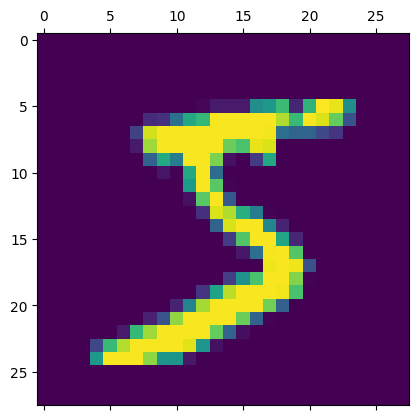

In [21]:
plt.matshow(x_train[0])

In [22]:
y_train[0]

5

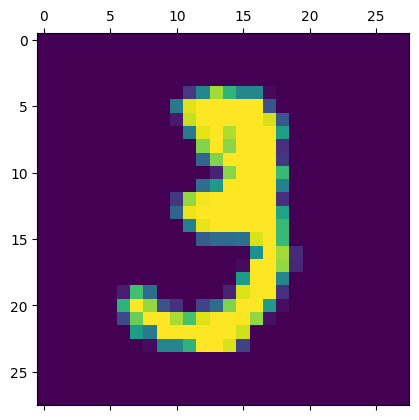

In [23]:
plt.matshow(x_train[10])

In [24]:
y_train[10]

3

In [25]:
x_train=x_train/255
x_test=x_test/255

In [32]:
x_train=np.expand_dims(x_train,-1)
x_test=np.expand_dims(x_test,-1)

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data=ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    horizontal_flip=True,
)

In [34]:
data.fit(x_train)

In [36]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten

In [ ]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [43]:
model.fit(x_train,y_train,epochs=3,batch_size=512,validation_data=(x_test,y_test))

Epoch 1/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 52s 438ms/step - accuracy: 0.9919 - loss: 0.0251 - val_accuracy: 0.9873 - val_loss: 0.0381
Epoch 2/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 79s 416ms/step - accuracy: 0.9923 - loss: 0.0240 - val_accuracy: 0.9903 - val_loss: 0.0314
Epoch 3/3
118/118 ━━━━━━━━━━━━━━━━━━━━ 82s 416ms/step - accuracy: 0.9953 - loss: 0.0166 - val_accuracy: 0.9894 - val_loss: 0.0333


In [44]:
preds=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


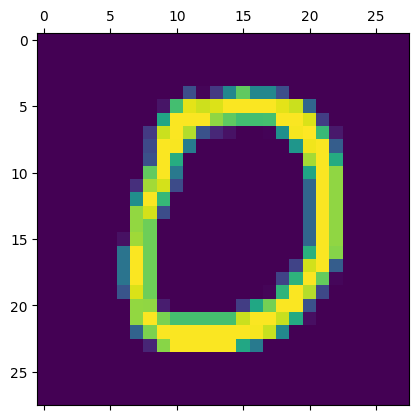

In [45]:
plt.matshow(x_test[10])

In [46]:
y_test[10]

0

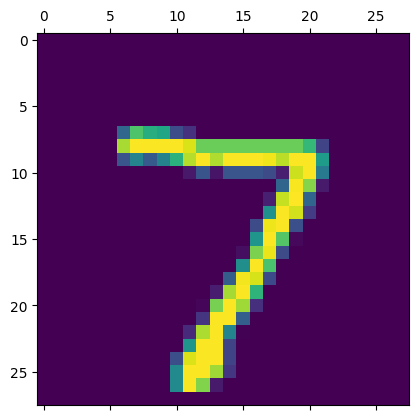

7


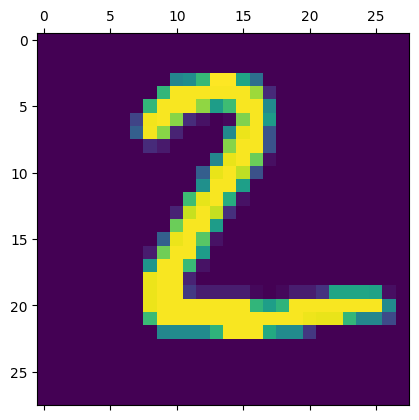

2


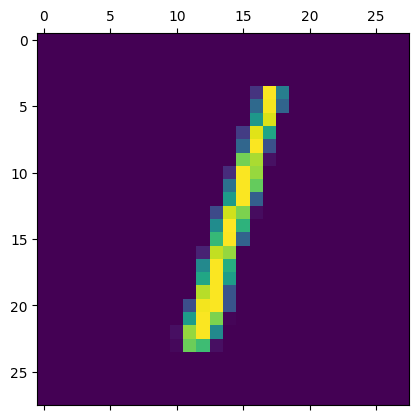

1


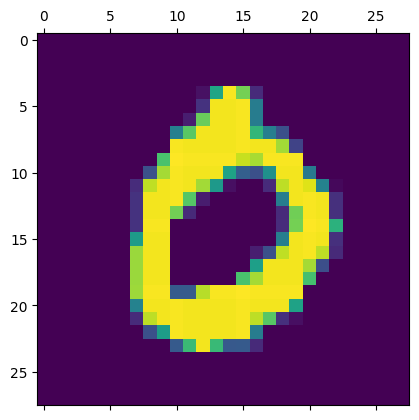

0


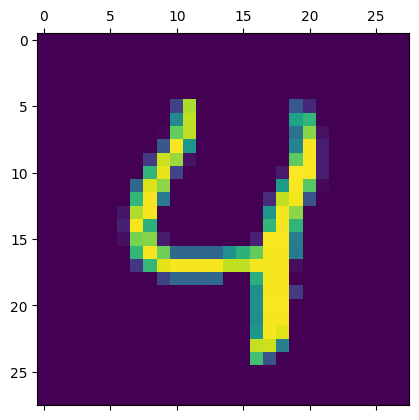

4


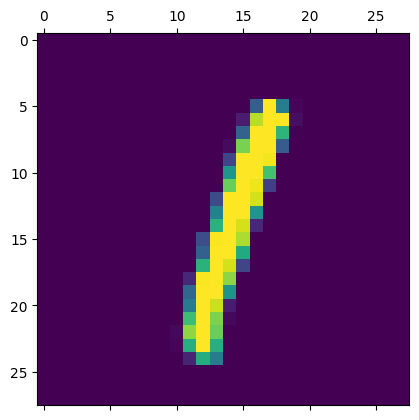

1


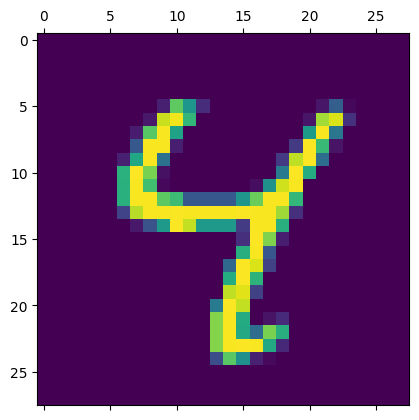

4


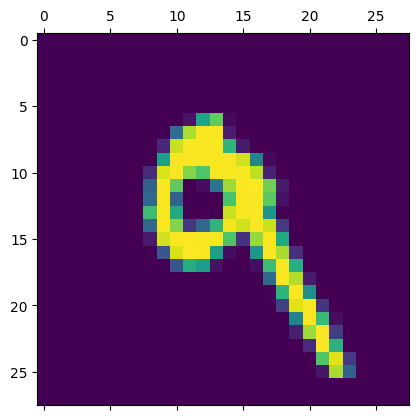

9


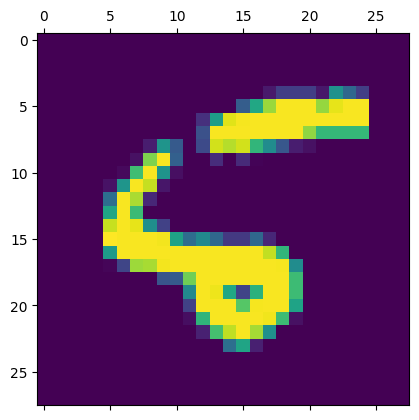

5


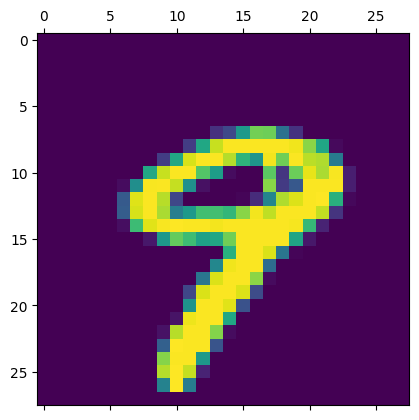

9


In [47]:
for i in range(10):
  plt.matshow(x_test[i])
  plt.show()
  print(np.argmax(preds[i]))